<a href="https://colab.research.google.com/github/kanebako-s/olist-data-analysis/blob/main/Kaggle_Olist_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## おまじない。

In [1]:
# --- ライブラリのインポート ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# --- グラフの見た目を整える ---
sns.set(style="whitegrid") # グラフにグリッド（網掛け）を出して見やすくする
plt.rcParams["figure.figsize"] = (10, 6) # グラフの基本サイズを少し大きくする

# --- データの表示設定 ---
pd.options.display.max_columns = None # 列数が多い時、省略（...）せずに全部表示する
pd.set_option('display.float_format', '{:.2f}'.format) # 小数点以下を2桁に固定して見やすくする

# --- 日本語化（重要！） ---
!pip install japanize-matplotlib
import japanize_matplotlib # これでグラフの日本語が「□」にならずに済む

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 70.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=e2bd205db0ac33b3089c1594ffc21e56cb145b8e0c1c412067be5112a4cdee8d
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


## ファイルの読み込み。

In [2]:
FILE_PATH = '/content/drive/MyDrive/Olist_Dateanalist_Learning' # ファイルの読み込みが自分専用になっている。あとで直しやすいようにしている。

customers_dataset = pd.read_csv(FILE_PATH + '/olist_customers_dataset.csv')
orders_dataset = pd.read_csv(FILE_PATH + '/olist_orders_dataset.csv')
order_reviews_dataset = pd.read_csv(FILE_PATH + '/olist_order_reviews_dataset.csv')



## それぞれのテーブルの中身を確認する。

In [3]:
# customers_dataset.head(0) # 注文番号と顧客の固有識別番号、顧客の州と街。


顧客データ（customers_dataset）の構造把握。
* ** 顧客の固有識別子の重複についての注意 ** customer_unique_idのデータが重複していたとしても、一回の注文で複数のものを頼んだ可能性もありECサイトを別日程で再利用したかどうかは本テーブルのみでは判別不能。

** 分析方針 **

真のリピート率は"orders_dataset"と結合後、"customer_unique_id"をキーとして"order_id"の数をカウントする。

"order_id"の数が１であれば「新規顧客」、

"order_id"の数が２以上であれば「リピーター」と定義する。

リピーターの1回目の注文の満足度スコアが高いことは想像がつきます。

新規顧客について、1回目の注文の満足度スコアが高いのに再利用してない人は注文物の品質は満足したが配送関係で信頼を損なった可能性がある。1回目の満足度スコアが高く配送時間のズレが大きい人は離脱しているかを確認する。

In [4]:
orders_dataset.head(3) # order_idを主キーとする注文履歴。注文申請時間から配達完了時間までの５種類のタイムスタンプ。
# タイムスタンプのデータ型を確認、修正。推定配達日と実際配達日のズレの計算で使いそうだから。

data_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for time_col in data_cols:
  orders_dataset[time_col] = pd.to_datetime(orders_dataset[time_col])

orders_dataset.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04


注文データ（orders_dataset）の構造確認と仮説の構築。

* ** 推定配達日と実際配達日にズレについて ** 推定配達日より二週間早くと届く場合もあれば、二週間遅く届く日もあることが確認できた。この推定配達日のズレは信頼性を損ない顧客満足度に影響すると予想できる。
* ** 配達時間について ** 配達時間は地域性に依存するものの、同じ地域内でも配達時間にばらつきがあり、それが顧客満足度に影響している可能性がある。

** 分析方針 **

* 推定配達日と実際配達日のズレの日数を算出し、満足度スコアとの相関を可視化し確認する。
* 「地域」ごとの配達時間の分散を算出し満足度スコアの低くなる特定の地域を探る。


In [5]:
order_reviews_dataset.head(20) # レビューの固有識別子、満足度スコア、コメント、レビュー作成時間、レビューに対する運営の回答時間。

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


レビューデータ（order_reviews_dataset）の構造確認と評価指標の選定。

** レビューデータ確認による洞察 **
* ** 運営の対応速度について ** レビューが投稿されてから運営が回答するまでの時間はこの２０件の中では最大７日だった。このデータはリピート率に影響していなさそう。
* ** コメントをする人の割合について **コメントタイトルとコメントは書いている人の割合が少ない。一部のユーザーの意見で全体の傾向は測れないため指標として不適。

** 分析方針 **

レビューデータでは、満足度スコアのみを主要な指標にすることでリピート率の向上に役立てる。満足度スコア１がリピート率に与える影響を確認する。

## 分析と可視化

In [6]:
# ３つのテーブルを一つにまとめる。
df_temp = pd.merge(orders_dataset, customers_dataset, on='customer_id')
df_final = pd.merge(df_temp, order_reviews_dataset, on='order_id')

In [13]:
# 満足度スコア１がリピート率に与える影響を確認する。

# スコア1の注文だけを抽出
score_1_orders = df_final[df_final['review_score'] == 1].copy()

# 顧客ごとに、最も古い（最初の）スコア1の日付を取得
first_score_1_date = score_1_orders.groupby('customer_unique_id')['order_purchase_timestamp'].min().reset_index()
first_score_1_date.columns = ['customer_unique_id', 'first_score_1_at']

# 元のデータに「最初のスコア1の日付」を結合
df_final = pd.merge(df_final, first_score_1_date, on='customer_unique_id', how='left')

# スコア1を付けた日よりも後の日付の注文があれば True
df_final['is_order_after_score_1'] = df_final['order_purchase_timestamp'] > df_final['first_score_1_at']

# スコア1経験済みリピート者/スコア1経験済みの全顧客が知りたい。
# スコア1を経験した人だけに絞る
affected_customers = df_final[df_final['first_score_1_at'].notnull()]

# 顧客ごとに、一度でも「スコア1後の注文」があるかを確認
churn_analysis = affected_customers.groupby('customer_unique_id')['is_order_after_score_1'].any().value_counts()

print("スコア1を付けた後のリピート状況:")
print(churn_analysis)

スコア1を付けた後のリピート状況:
is_order_after_score_1
False    10863
True       330
Name: count, dtype: int64


満足度スコア１がリピート率に与える影響について。

** 分析結果 **

* 満足度スコア１を付けたことのある顧客は、その９７％がその後二度と注文していない事が確認できた。

* これにより満足度スコア１は単なる不満ではなく、明確な離脱要因となっている事がわかる。

** 分析方針 **

満足度スコア１と評価した原因を特定し、その改善ができればリピート率向上に繋がる。

「配送遅延」「商品不備」「価格相応でない」などからスコア１の不満の主因となっているものを特定する。

離脱した97%の顧客が本来もたらしたであろうLTV（顧客生涯価値）を算出し、改善による経済的インパクトを可視化する。

In [8]:
# 予定配達日ー実際配達日＝配達日のズレ　（＋なら早く届いたと言う事。ーなら遅延したと言う事。０が一番良い。）
df_final['delivery_diff'] = (df_final['order_estimated_delivery_date'] - df_final['order_delivered_customer_date']).dt.days

df_final[['delivery_diff', 'review_score', 'customer_unique_id','order_estimated_delivery_date', 'order_delivered_customer_date']].head(20)

df_final['delivery_diff'].describe() # 予定より早く配達されることが多いことが明確になった。半年遅れや半年早く届くこともあるらしい。

,delivery_diff
count,96359.00
mean,10.92
std,10.11
min,-189.00
25%,6.00
50%,11.00
75%,16.00
max,146.00


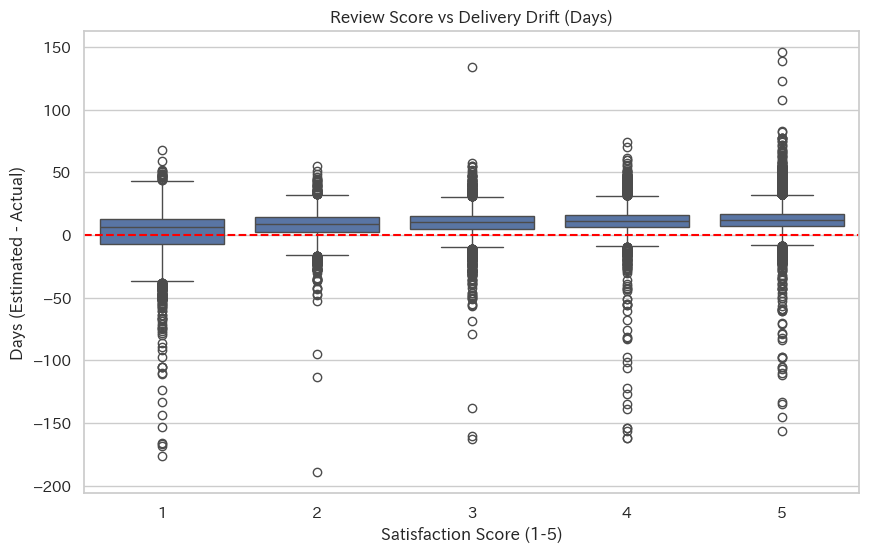

In [9]:
# 配送のズレと満足度スコアの関係を可視化。
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_diff', data=df_final)
plt.title('Review Score vs Delivery Drift (Days)')
plt.xlabel('Satisfaction Score (1-5)')
plt.ylabel('Days (Estimated - Actual)')
plt.axhline(0, color='red', linestyle='--') # 0日の線（予定通り）
plt.show()

可視化による満足度スコアと配送のズレの大きさの関係性の確認。


** 分析結果 **

* 配達が遅延していても満足度が５になることある。
早く配達されても満足度が１になることも多い。
* 満足度スコア１のグループは他と比べて顕著に遅延が大きい

** 結論と次の仮説 **
満足度スコアが１の要因として遅延の大きさもあるが、予定より早期に配達されてもスコアが１になっている件は、不満の原因が「配達」ではなく「商品の状態」にある可能性が高い。

特定の地域の配送業者が商品を手荒に扱っていると仮説を立てて、次は地域ごとの満足度スコア分布を確認する。

In [10]:
# 地域（customer_state）ごとに、スコアとズレの平均・標準偏差（ばらつき）を計算
state_analysis = df_final.groupby('customer_state').agg({
    'review_score': 'mean',
    'delivery_diff': ['mean', 'std'], # 平均と標準偏差（ばらつき）
    'order_id': 'count'               # 注文数（データが少なすぎる地域を除外するため）
}).reset_index()

# カラムの名前を分かりやすくする。
state_analysis.columns = ['state', 'score_mean', 'diff_mean', 'diff_std', 'order_count']

# 注文件数の極端に少ない地域はノイズになるので除外し、スコアが低い地域順に並べ替える。
worst_state = state_analysis[state_analysis['order_count'] > 100].sort_values(by='score_mean')

# 各州ごとに、スコア1が占める割合（％）を計算する
state_bad_rate = df_final.groupby('customer_state').apply(
    lambda x: (x['review_score'] == 1).sum() / len(x) * 100
).reset_index(name='score_1_rate')

# worst_stateとstate_bad_rateを結合して、割合が高い順に並べる
worst_rate_state = worst_state.merge(state_bad_rate, left_on='state', right_on='customer_state')
worst_rate_state[worst_rate_state['order_count'] > 100].sort_values(by='score_1_rate', ascending=False).head(10)


worst_rate_state.reset_index().head(23)

/tmp/ipykernel_1900/650856113.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  state_bad_rate = df_final.groupby('customer_state').apply(


,index,state,score_mean,diff_mean,diff_std,order_count,customer_state,score_1_rate
0,0,AL,3.75,7.82,13.08,414,AL,17.63
1,1,MA,3.76,8.72,14.07,746,MA,17.56
2,2,SE,3.81,9.07,17.83,349,SE,18.05
3,3,PA,3.85,13.18,13.86,968,PA,16.01
4,4,CE,3.85,9.87,14.40,1329,CE,15.80
5,5,BA,3.86,9.89,12.62,3357,BA,15.01
6,6,RJ,3.87,10.82,13.39,12765,RJ,17.10
7,7,PI,3.92,10.29,16.19,491,PI,14.66
8,8,PE,4.01,12.42,11.92,1646,PE,13.43
9,9,PB,4.02,12.46,11.33,531,PB,12.24


特定の地域の配送業者の配達品質が引くのでは、と言う予想についての確認。

** 分析結果 **

* 特定の地域に、満足度の低い顧客が偏っていることは確認できなかった。
* 各地域で配達予定日より平均１０日程度早く配達されていること分かる。このことから予定配達日の設定は当てにならないものであり、顧客の信頼性を損なう一因になっているものと予想される。

** 分析方針 **

予定配送日より遅延している件は特定地域に集中しているわけではないことが確認できた。次は特定の商品カテゴリに遅延が集中しているものと仮説を立てて、追加でorder_items_dataset、products_dataset、category_nameのファイルを読み込み、結合し、商品カテゴリごとにグループ化し、それぞれの'diff_mean'、'score_1_rate'を確認する。（クリスマス用品やパーティー用品などの配送遅延が致命的な商品カテゴリに注目する）

## ファイルの読み込み ２


In [11]:
order_items_dataset = pd.read_csv(FILE_PATH + '/olist_order_items_dataset.csv')
products_dataset = pd.read_csv(FILE_PATH + '/olist_products_dataset.csv')
product_name_translation = pd.read_csv(FILE_PATH + '/product_category_name_translation.csv')